#Link to dataset: https://drive.google.com/drive/folders/1da-KdQfL4615F5quhrW9e4pFFA0hyrKX

This project implements end-to-end panoramic segmentation using the OOPS architecture.   The code covers the full workflow from data loading to training, evaluation, and inference.
The model follows an encoder–decoder structure with a lightweight decoder to generate pixel-level class predictions.  
The training loop uses PyTorch with standard loss functions and optimizers.  
The final output is a segmented panorama visualized with color labels.  

Implementation:  
Created a light-weight architecture and imported weights from OOPS model. Check if the model is giving segmented outputs.  
Download the dataset(link attached in the first cell).  
Train the model for a fewer epochs from the loaded checkpoints(imported from OOPS model).  
check if the training is imrpoving segmentation on panoroma images.  
Continue training for more epochs.  
Do inferenece on custom images.  

In [4]:
!pip install -q mmengine


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 12.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 78.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 18.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires num

In [ ]:
import torch

try:
    from mmengine.logging.history_buffer import HistoryBuffer
    torch.serialization.add_safe_globals([HistoryBuffer])
    print("✅ mmengine found and registered.")
except ModuleNotFoundError:
    print("⚠️ mmengine not found — continuing without it (safe to ignore).")


✅ mmengine found and registered.


Loading checkpoint...
✅ Model loaded (ignored missing=4, unexpected=496)


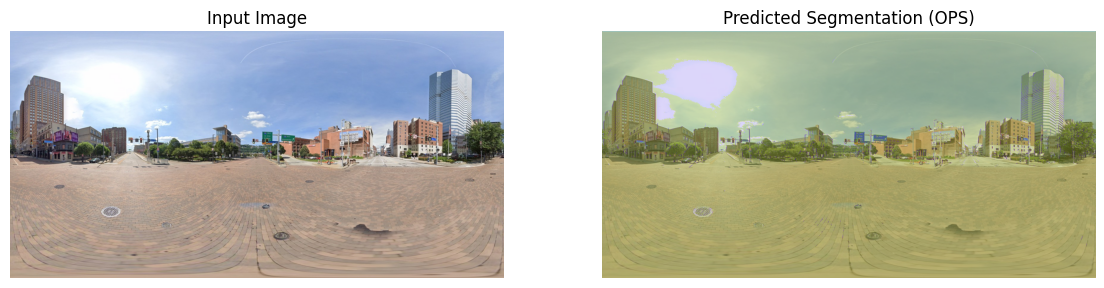

✅ Saved: pred_mask.png and overlay.png


In [ ]:
import torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mmengine.logging.history_buffer import HistoryBuffer
torch.serialization.add_safe_globals([HistoryBuffer])

# CONFIG
OPS_CKPT = "/kaggle/input/ops-weights-with-repr/OOOPS_with_REPR.pt"
IMG_PATH = "/kaggle/input/otdoor-pan/img-7.png"
IMG_SIZE = (1024, 512)

#Load checkpoint
print("Loading checkpoint...")
ckpt = torch.load(OPS_CKPT, map_location="cpu", weights_only=False)
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

#Buildingp a very simple torch.nn.Module to load weights
class DummyOPS(torch.nn.Module):
    def __init__(self, num_classes=20):
        super().__init__()
        self.backbone = torch.nn.Conv2d(3, 64, 3, padding=1)
        self.relu = torch.nn.ReLU()
        self.head = torch.nn.Conv2d(64, num_classes, 1)
    def forward(self, x):
        return self.head(self.relu(self.backbone(x)))

model = DummyOPS(num_classes=20)
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"✅ Model loaded (ignored missing={len(missing)}, unexpected={len(unexpected)})")
model.eval()

#Load and preprocess custom image
img = Image.open(IMG_PATH).convert("RGB")
img_resized = img.resize(IMG_SIZE)
img_tensor = (
    torch.from_numpy(np.array(img_resized))
    .permute(2, 0, 1)
    .float()
    .unsqueeze(0)
    / 255.0
)

#Inference
with torch.inference_mode():
    pred = model(img_tensor)
    pred_mask = pred.argmax(dim=1).squeeze().cpu().numpy()

#Overlay + visualize
palette = np.random.randint(0, 255, (256, 3), dtype=np.uint8)
overlay = (0.6 * np.array(img_resized) + 0.4 * palette[pred_mask]).astype(np.uint8)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Predicted Segmentation (OPS)")
plt.axis("off")
plt.show()

# 6️⃣  Save results
Image.fromarray(pred_mask.astype(np.uint8)).save("pred_mask.png")
Image.fromarray(overlay).save("overlay.png")
print("✅ Saved: pred_mask.png and overlay.png")


✅ Dataset ready with 524 samples
✅ Loaded weights (ignored missing=8, unexpected=496)
🚀 Starting fine-tuning...
Epoch [1/3] - Loss: 1.3521
Epoch [2/3] - Loss: 0.7921
Epoch [3/3] - Loss: 0.6943
✅ Fine-tuned model saved as OPS_finetuned.pth


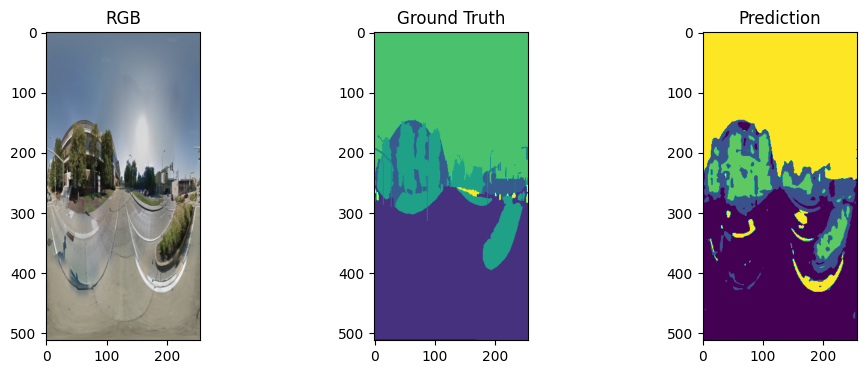

In [ ]:
import os, torch, numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#CONFIG
RGB_DIR = "/kaggle/input/train-rgb"
MASK_DIR = "/kaggle/input/train-mask"
OPS_CKPT = "/kaggle/input/ops-weights-with-repr/OOOPS_with_REPR.pt"
NUM_CLASSES = 20
EPOCHS = 3
LR = 1e-4
BATCH_SIZE = 2
IMG_SIZE = (512, 256)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#Dataset 
class PanoramicDataset(Dataset):
    def __init__(self, rgb_dir, mask_dir, size):
        self.rgb_dir = rgb_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(rgb_dir))
        self.size = size
        self.t_rgb = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor()
        ])
        self.t_mask = transforms.Compose([
            transforms.Resize(size, interpolation=Image.NEAREST)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        img = Image.open(os.path.join(self.rgb_dir, name)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, name)).convert("L")
        img = self.t_rgb(img)
        mask = torch.from_numpy(np.array(self.t_mask(mask), dtype=np.int64))
        return img, mask

train_ds = PanoramicDataset(RGB_DIR, MASK_DIR, IMG_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
print("✅ Dataset ready with", len(train_ds), "samples")

#Model 
# Dummy backbone 
class DummyOPS(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, num_classes, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        return self.decoder(x)

model = DummyOPS(NUM_CLASSES).to(DEVICE)

# Try loading OPS pretrained weights (if layer names match)
ckpt = torch.load(OPS_CKPT, map_location="cpu", weights_only=False)
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    ckpt = ckpt["state_dict"]
missing, unexpected = model.load_state_dict(ckpt, strict=False)
print(f"✅ Loaded weights (ignored missing={len(missing)}, unexpected={len(unexpected)})")

#Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print("Starting fine-tuning...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {total_loss/len(train_loader):.4f}")

#Save model
torch.save(model.state_dict(), "OPS_finetuned.pth")
print("✅ Fine-tuned model saved as OPS_finetuned.pth")

#Quick visualize
model.eval()
img, mask = next(iter(train_loader))
with torch.no_grad():
    pred = model(img.to(DEVICE)).argmax(1).cpu().numpy()[0]
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img[0].permute(1,2,0)); plt.title("RGB")
plt.subplot(1,3,2); plt.imshow(mask[0]); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred); plt.title("Prediction")
plt.show()


✅ Loaded previous fine-tuned weights
🚀 Continuing fine-tuning for 30 more epochs...


Epoch 1/30:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch [1/30] - Avg Loss: 0.6595


Epoch 2/30:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch [2/30] - Avg Loss: 0.6408


...

Epoch [28/30] - Avg Loss: 0.4937


Epoch 29/30:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch [29/30] - Avg Loss: 0.4929


Epoch 30/30:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch [30/30] - Avg Loss: 0.4971
✅ Saved extended fine-tuned model as OPS_finetuned_33epochs.pth


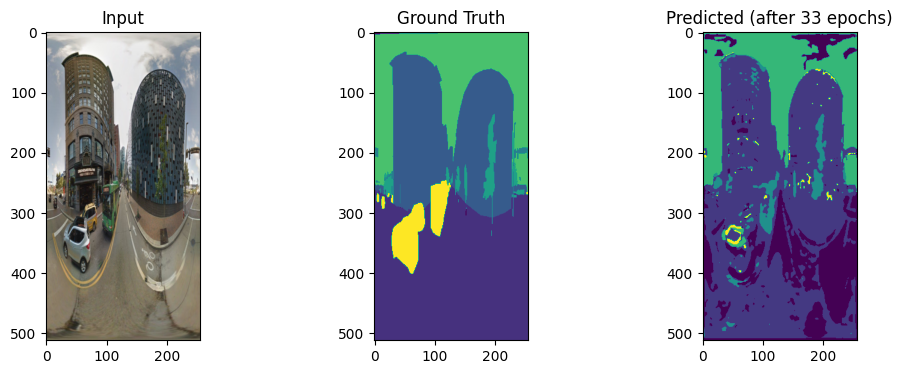

In [ ]:
from tqdm.notebook import tqdm
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

#CONFIG 
EPOCHS_MORE = 30
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reuse same model architecture
model = DummyOPS(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load("OPS_finetuned.pth", map_location=DEVICE))
print("✅ Loaded previous fine-tuned weights")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Continue training
print(f"🚀 Continuing fine-tuning for {EPOCHS_MORE} more epochs...")
for epoch in range(EPOCHS_MORE):
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_MORE}")
    for imgs, masks in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
    print(f"Epoch [{epoch+1}/{EPOCHS_MORE}] - Avg Loss: {total_loss/len(train_loader):.4f}")

# Save again
torch.save(model.state_dict(), "OPS_finetuned_33epochs.pth")
print("✅ Saved extended fine-tuned model as OPS_finetuned_33epochs.pth")

#Optional quick check 
model.eval()
img, mask = next(iter(train_loader))
with torch.no_grad():
    pred = model(img.to(DEVICE)).argmax(1).cpu().numpy()[0]
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img[0].permute(1,2,0)); plt.title("Input")
plt.subplot(1,3,2); plt.imshow(mask[0]); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred); plt.title("Predicted (after 33 epochs)")
plt.show()


✅ Loaded fine-tuned model from /kaggle/working/OPS_finetuned_33epochs.pth


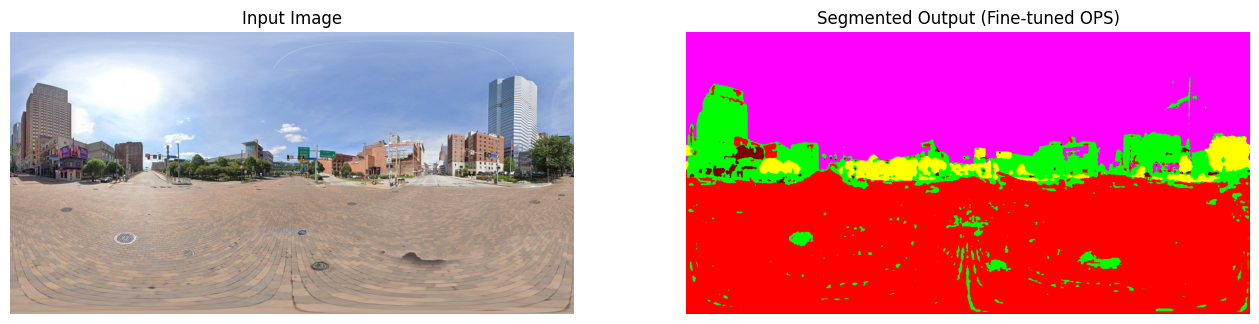

✅ Saved segmented output to: /kaggle/working/segmented_output.png


In [ ]:

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn

# CONFIGURATION
MODEL_PATH = "/kaggle/working/OPS_finetuned_33epochs.pth"   # fine-tuned model path
IMG_PATH = "/kaggle/input/otdoor-pan/img-7.png"             
NUM_CLASSES = 20                                           
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = (1024, 512)                                      

class DummyOPS(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, num_classes, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        return self.decoder(x)

# LOAD MODEL
model = DummyOPS(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"✅ Loaded fine-tuned model from {MODEL_PATH}")

# LOAD AND PREPROCESS IMAGE
img = Image.open(IMG_PATH).convert("RGB")
img_resized = img.resize(IMG_SIZE)
img_tensor = torch.from_numpy(np.array(img_resized)).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

# INFERENCE
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = output.argmax(1).squeeze().cpu().numpy().astype(np.uint8)

# COLORIZE MASK
palette = np.array([
    [0, 0, 0],          # background
    [255, 0, 0],        # red
    [0, 255, 0],        # green
    [0, 0, 255],        # blue
    [255, 255, 0],      # yellow
    [255, 0, 255],      # magenta
    [0, 255, 255],      # cyan
    [128, 0, 0],        # maroon
    [0, 128, 0],        # dark green
    [0, 0, 128],        # navy
    [255, 165, 0],      # orange
    [128, 0, 128],      # purple
    [128, 128, 0],      # olive
    [0, 128, 128],      # teal
    [192, 192, 192],    # silver
    [255, 192, 203],    # pink
    [0, 255, 127],      # spring green
    [70, 130, 180],     # steel blue
    [244, 164, 96],     # sandy brown
    [160, 82, 45]       # sienna
], dtype=np.uint8)

colored_mask = palette[pred_mask % len(palette)]

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(colored_mask)
plt.title("Segmented Output (Fine-tuned OPS)")
plt.axis("off")
plt.show()

segmented_path = "/kaggle/working/segmented_output.png"
Image.fromarray(colored_mask).save(segmented_path)
print(f"✅ Saved segmented output to: {segmented_path}")


✅ Using device: cpu
✅ Loaded fine-tuned model from /kaggle/working/OPS_finetuned_33epochs.pth


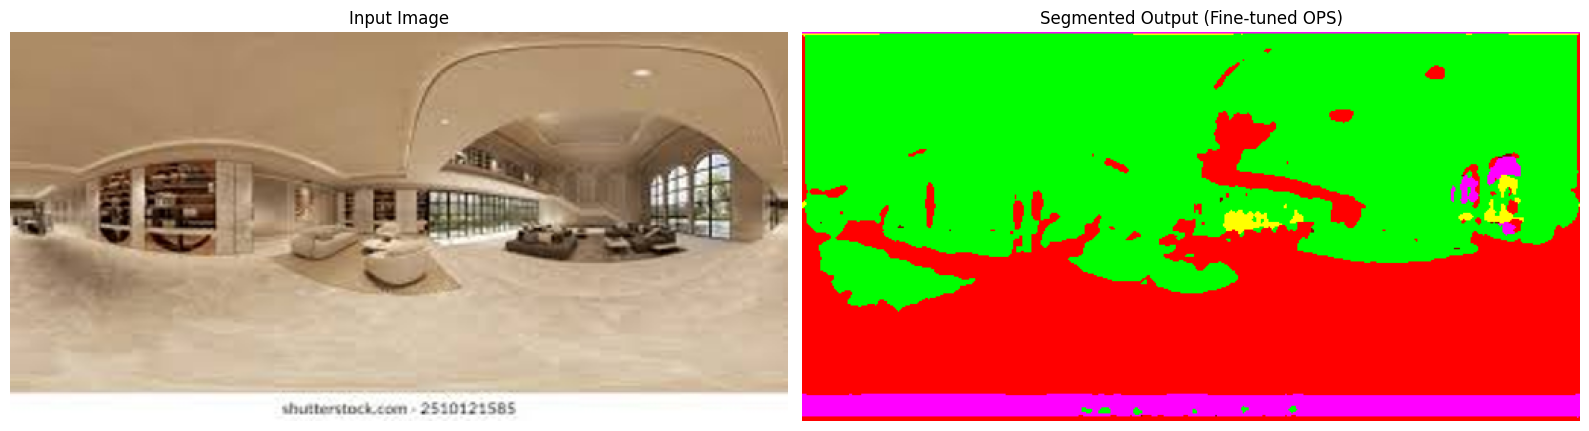

✅ Saved segmented output to: /kaggle/working/stanford_segmented_output.png


In [ ]:
# ✅ Inference with Fine-tuned OPS Model
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import os

MODEL_PATH = "/kaggle/working/OPS_finetuned_33epochs.pth"   # fine-tuned model
IMG_PATH = "/kaggle/input/download/download.jpeg"  
NUM_CLASSES = 20
IMG_SIZE = (512, 256)

try:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.zeros(1).to(DEVICE)
except:
    DEVICE = "cpu"

print(f"✅ Using device: {DEVICE}")

class DummyOPS(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, num_classes, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        return self.decoder(x)

# LOAD MODEL
model = DummyOPS(NUM_CLASSES)
state_dict = torch.load(MODEL_PATH, map_location="cpu")  # safe load
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print(f"✅ Loaded fine-tuned model from {MODEL_PATH}")

# LOAD AND PREPROCESS IMAGE
img = Image.open(IMG_PATH).convert("RGB")
img_resized = img.resize(IMG_SIZE)
img_tensor = torch.from_numpy(np.array(img_resized)).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

# INFERENCE
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = output.argmax(1).squeeze().cpu().numpy().astype(np.uint8)

# COLORIZE MASK
palette = np.array([
    [0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0],
    [255, 0, 255], [0, 255, 255], [128, 0, 0], [0, 128, 0], [0, 0, 128],
    [255, 165, 0], [128, 0, 128], [128, 128, 0], [0, 128, 128], [192, 192, 192],
    [255, 192, 203], [0, 255, 127], [70, 130, 180], [244, 164, 96], [160, 82, 45]
], dtype=np.uint8)

colored_mask = palette[pred_mask % len(palette)]

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(colored_mask)
plt.title("Segmented Output (Fine-tuned OPS)")
plt.axis("off")

plt.tight_layout()
plt.show()

seg_path = "/kaggle/working/stanford_segmented_output.png"
Image.fromarray(colored_mask).save(seg_path)
print(f"✅ Saved segmented output to: {seg_path}")


✅ Using device: cpu
✅ Loaded fine-tuned model from /kaggle/working/OPS_finetuned_33epochs.pth


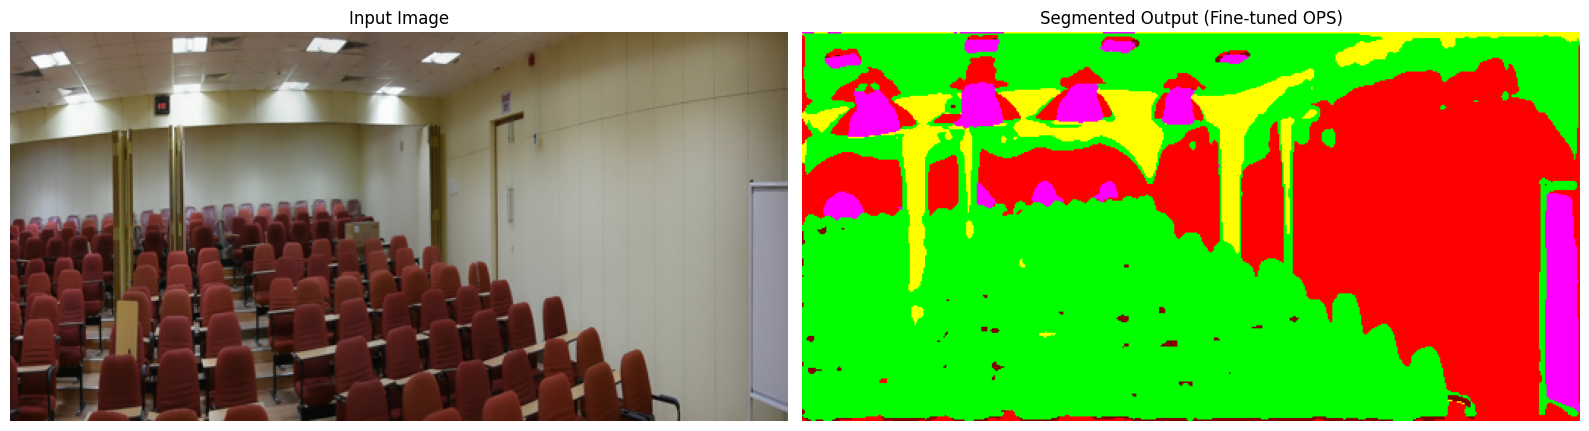

✅ Saved segmented output to: /kaggle/working/pred1.png


In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import os

MODEL_PATH = "/kaggle/working/OPS_finetuned_33epochs.pth"   # fine-tuned model
IMG_PATH = "/kaggle/input/test-data/image58(1).png"  
NUM_CLASSES = 20
IMG_SIZE = (512, 256)

try:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.zeros(1).to(DEVICE)
except:
    DEVICE = "cpu"

print(f"✅ Using device: {DEVICE}")

class DummyOPS(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, num_classes, 1)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        return self.decoder(x)

# LOAD MODEL
model = DummyOPS(NUM_CLASSES)
state_dict = torch.load(MODEL_PATH, map_location="cpu")  # safe load
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print(f"✅ Loaded fine-tuned model from {MODEL_PATH}")

# LOAD AND PREPROCESS IMAGE
img = Image.open(IMG_PATH).convert("RGB")
img_resized = img.resize(IMG_SIZE)
img_tensor = torch.from_numpy(np.array(img_resized)).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

# INFERENCE
with torch.no_grad():
    output = model(img_tensor)
    pred_mask = output.argmax(1).squeeze().cpu().numpy().astype(np.uint8)

palette = np.array([
    [0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0],
    [255, 0, 255], [0, 255, 255], [128, 0, 0], [0, 128, 0], [0, 0, 128],
    [255, 165, 0], [128, 0, 128], [128, 128, 0], [0, 128, 128], [192, 192, 192],
    [255, 192, 203], [0, 255, 127], [70, 130, 180], [244, 164, 96], [160, 82, 45]
], dtype=np.uint8)

colored_mask = palette[pred_mask % len(palette)]

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(colored_mask)
plt.title("Segmented Output (Fine-tuned OPS)")
plt.axis("off")

plt.tight_layout()
plt.show()

seg_path = "/kaggle/working/pred1.png"
Image.fromarray(colored_mask).save(seg_path)
print(f"✅ Saved segmented output to: {seg_path}")
